In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
import zipfile
import os

ZIP_PATH = "/content/drive/MyDrive/leukemia-dataset.zip"
EXTRACT_PATH = "/content/drive/MyDrive"

if not os.path.exists("/content/leukemia-dataset"):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("✅ Dataset extracted")
else:
    print("✅ Dataset already exists")

✅ Dataset extracted


In [25]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split
import torchvision.models as models
import json

In [26]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7,1.0)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),

    transforms.ColorJitter(
        brightness=0.4,
        contrast=0.4,
        saturation=0.3,
        hue=0.08
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [27]:
DATA_PATH = "/content/drive/MyDrive/leukemia-dataset"

train_dir = os.path.join(DATA_PATH, "train")
test_dir = os.path.join(DATA_PATH, "test")

full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=val_transform)

class_names = full_train_dataset.classes
print("Classes:", class_names)

Classes: ['healthy', 'leukemia']


In [28]:
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

In [29]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [30]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        weights = torch.softmax(self.attn(x), dim=1)
        context = (weights * x).sum(dim=1)
        return context


class CNN_GRU_Attention(nn.Module):
    def __init__(self):
        super().__init__()

        base_model = models.resnet18(weights="IMAGENET1K_V1")

        # 🔥 Freeze early layers (reduces overfitting)
        for param in list(base_model.parameters())[:-20]:
            param.requires_grad = False

        self.feature_extractor = nn.Sequential(*list(base_model.children())[:-1])

        self.gru = nn.GRU(512, 256, batch_first=True)

        self.attention = Attention(256)

        # 🔥 Stronger regularization
        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)

        x = x.unsqueeze(1)  # (B, 1, 512)

        x, _ = self.gru(x)
        x = self.attention(x)

        x = self.fc(x)
        return x

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN_GRU_Attention().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

In [32]:
print(device)

cuda


In [39]:
SAVE_PATH = "/content/drive/MyDrive/leukemia_checkpoint.pth"

start_epoch = 0
best_loss = float('inf')

if os.path.exists(SAVE_PATH):
    print("🔁 Loading checkpoint...")

    checkpoint = torch.load(SAVE_PATH)

    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])

    start_epoch = checkpoint['epoch']
    best_loss = checkpoint['best_loss']

    print(f"✅ Resuming from epoch {start_epoch}")

🔁 Loading checkpoint...
✅ Resuming from epoch 20


In [41]:
import os

# =========================
# PATHS
# =========================
SAVE_PATH = "/content/drive/MyDrive/leukemia_checkpoint.pth"
BEST_MODEL_PATH = "/content/drive/MyDrive/leukemia_best_model.pth"
LATEST_MODEL_PATH = "/content/drive/MyDrive/leukemia_latest_model.pth"


# =========================
# LOAD CHECKPOINT
# =========================
start_epoch = 0
best_loss = float('inf')

if os.path.exists(SAVE_PATH):
    print("📦 Loading checkpoint...")

    checkpoint = torch.load(SAVE_PATH)

    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])

    start_epoch = checkpoint['epoch']
    best_loss = checkpoint['best_loss']

    print(f"✅ Resuming from epoch {start_epoch}")
else:
    print("🚀 Starting fresh training")


# =========================
# SCHEDULER (FIXED)
# =========================
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)


# =========================
# TRAINING CONFIG
# =========================
EPOCHS = 20   # 🔥 NEW epochs to run

print(f"\n🔁 Resuming from epoch {start_epoch}")
print(f"🎯 Training for {EPOCHS} more epochs → till {start_epoch + EPOCHS}\n")


# =========================
# TRAINING LOOP
# =========================
for epoch in range(start_epoch, start_epoch + EPOCHS):
    print(f"\n🚀 Epoch {epoch+1}/{start_epoch + EPOCHS}")

    # -----------------------
    # TRAIN
    # -----------------------
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()

        # 🔥 Stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        train_loss += loss.item()

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = (train_correct / train_total) * 100

    # -----------------------
    # VALIDATION
    # -----------------------
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = (val_correct / val_total) * 100

    # -----------------------
    # LR SCHEDULER
    # -----------------------
    scheduler.step(val_loss)

    # Optional: print LR
    print("📉 LR:", optimizer.param_groups[0]['lr'])

    # -----------------------
    # PRINT RESULTS
    # -----------------------
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # -----------------------
    # SAVE BEST MODEL
    # -----------------------
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("🔥 Best Model Updated")

    # -----------------------
    # SAVE CHECKPOINT
    # -----------------------
    torch.save({
        'epoch': epoch + 1,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'best_loss': best_loss
    }, SAVE_PATH)

    print("💾 Checkpoint Saved")

    # -----------------------
    # SAVE LATEST MODEL
    # -----------------------
    torch.save(model.state_dict(), LATEST_MODEL_PATH)
    print("🔄 Latest Model Saved")

📦 Loading checkpoint...
✅ Resuming from epoch 20

🔁 Resuming from epoch 20
🎯 Training for 20 more epochs → till 40


🚀 Epoch 21/40
📉 LR: 5e-05
Train Loss: 0.0435 | Train Acc: 98.81%
Val Loss: 0.0215 | Val Acc: 99.16%
💾 Checkpoint Saved
🔄 Latest Model Saved

🚀 Epoch 22/40
📉 LR: 5e-05
Train Loss: 0.0304 | Train Acc: 99.09%
Val Loss: 0.0294 | Val Acc: 98.61%
💾 Checkpoint Saved
🔄 Latest Model Saved

🚀 Epoch 23/40
📉 LR: 5e-05
Train Loss: 0.0256 | Train Acc: 99.16%
Val Loss: 0.0284 | Val Acc: 98.61%
💾 Checkpoint Saved
🔄 Latest Model Saved

🚀 Epoch 24/40
📉 LR: 5e-05
Train Loss: 0.0291 | Train Acc: 98.95%
Val Loss: 0.0094 | Val Acc: 99.72%
🔥 Best Model Updated
💾 Checkpoint Saved
🔄 Latest Model Saved

🚀 Epoch 25/40
📉 LR: 5e-05
Train Loss: 0.0269 | Train Acc: 98.88%
Val Loss: 0.0117 | Val Acc: 99.44%
💾 Checkpoint Saved
🔄 Latest Model Saved

🚀 Epoch 26/40
📉 LR: 5e-05
Train Loss: 0.0485 | Train Acc: 98.40%
Val Loss: 0.0202 | Val Acc: 98.89%
💾 Checkpoint Saved
🔄 Latest Model Saved

🚀 Epoch 27/40
📉 

Folders in dataset: ['test', 'train']


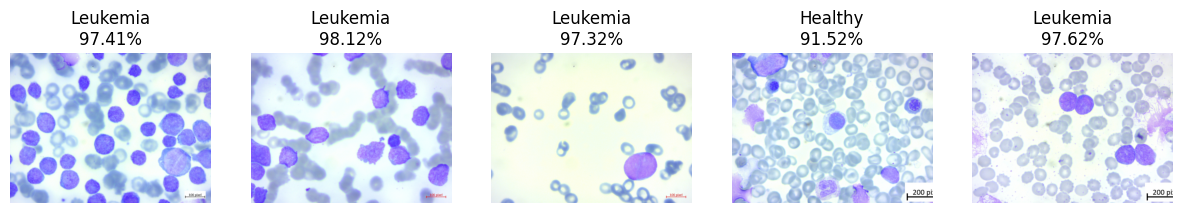

In [42]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os
import torch

# =========================
# LOAD BEST MODEL
# =========================
model.load_state_dict(torch.load("/content/drive/MyDrive/leukemia_model.pth"))
model.eval()

class_names = ["Healthy", "Leukemia"]


# =========================
# PREDICTION FUNCTION (UPDATED)
# =========================
def predict_image(img_path):
    image = Image.open(img_path).convert("RGB")
    img = val_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)

        # 🔥 Confidence scaling (FIX OVERCONFIDENCE)
        prob = torch.sigmoid(output / 2).item()

    # 🔥 Better threshold
    prediction = "Leukemia" if prob > 0.6 else "Healthy"
    confidence = prob if prob > 0.6 else 1 - prob

    return prediction, confidence


# =========================
# LOAD TEST IMAGES
# =========================
test_root = "/content/drive/MyDrive/leukemia-dataset/test"

# Debug check
print("Folders in dataset:", os.listdir("/content/drive/MyDrive/leukemia-dataset"))

samples = []

for cls in os.listdir(test_root):
    cls_path = os.path.join(test_root, cls)

    # Safety check
    if not os.path.isdir(cls_path):
        continue

    for img in os.listdir(cls_path):
        samples.append(os.path.join(cls_path, img))


# =========================
# RANDOM SAMPLE TEST
# =========================
samples = random.sample(samples, 5)

plt.figure(figsize=(15,5))

for i, img_path in enumerate(samples):
    pred, conf = predict_image(img_path)

    img = Image.open(img_path)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(f"{pred}\n{conf*100:.2f}%")
    plt.axis("off")

plt.show()

In [43]:
import json

class_mapping = {
    "0": "Healthy",
    "1": "Leukemia"
}

with open("/content/drive/MyDrive/classes.json", "w") as f:
    json.dump(class_mapping, f)

print("✅ classes.json saved")

✅ classes.json saved


In [44]:
from google.colab import files
uploaded = files.upload()

Saving Sap_013 (39).jpg to Sap_013 (39).jpg


In [45]:
for img_name in uploaded.keys():
    pred, conf = predict_image(img_name)
    print(f"Prediction: {pred}")
    print(f"Confidence: {conf*100:.2f}%")

Prediction: Healthy
Confidence: 84.32%


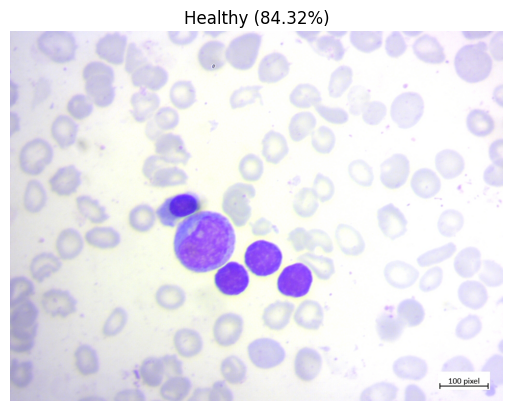

In [46]:
import matplotlib.pyplot as plt
from PIL import Image

for img_name in uploaded.keys():
    pred, conf = predict_image(img_name)

    img = Image.open(img_name)

    plt.imshow(img)
    plt.title(f"{pred} ({conf*100:.2f}%)")
    plt.axis("off")
    plt.show()

In [47]:
from google.colab import files
uploaded = files.upload()

Saving Sn1ap_024 (19).jpg to Sn1ap_024 (19).jpg


In [52]:
for img_name in uploaded.keys():
    pred, conf = predict_image(img_name)
    print(f"Prediction: {pred}")
    print(f"Confidence: {conf*100:.2f}%")

Prediction: Leukemia
Confidence: 98.18%


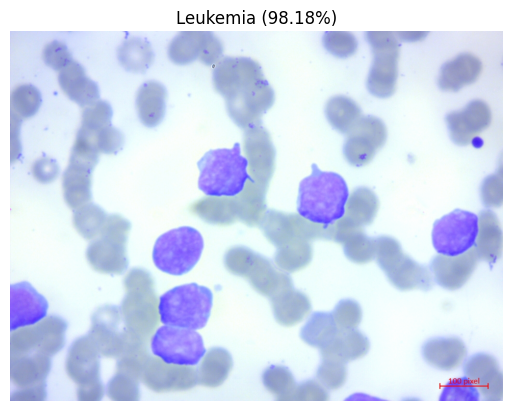

In [49]:
import matplotlib.pyplot as plt
from PIL import Image

for img_name in uploaded.keys():
    pred, conf = predict_image(img_name)

    img = Image.open(img_name)

    plt.imshow(img)
    plt.title(f"{pred} ({conf*100:.2f}%)")
    plt.axis("off")
    plt.show()

In [53]:
from google.colab import files
uploaded = files.upload()

Saving leukemia_test.png to leukemia_test.png


In [54]:
for img_name in uploaded.keys():
    pred, conf = predict_image(img_name)
    print(f"Prediction: {pred}")
    print(f"Confidence: {conf*100:.2f}%")

Prediction: Leukemia
Confidence: 96.11%


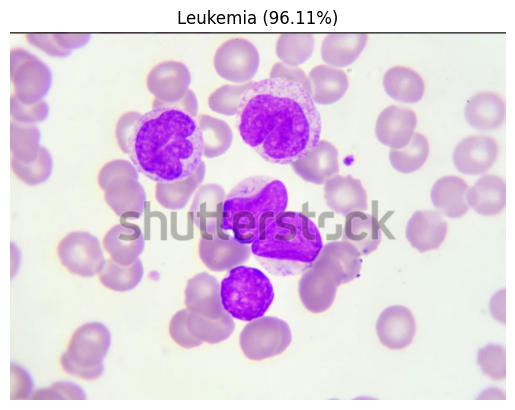

In [55]:
import matplotlib.pyplot as plt
from PIL import Image

for img_name in uploaded.keys():
    pred, conf = predict_image(img_name)

    img = Image.open(img_name)

    plt.imshow(img)
    plt.title(f"{pred} ({conf*100:.2f}%)")
    plt.axis("off")
    plt.show()

In [56]:
from google.colab import files
uploaded = files.upload()

Saving healthy_test.png to healthy_test.png


In [57]:
for img_name in uploaded.keys():
    pred, conf = predict_image(img_name)
    print(f"Prediction: {pred}")
    print(f"Confidence: {conf*100:.2f}%")

Prediction: Healthy
Confidence: 44.39%


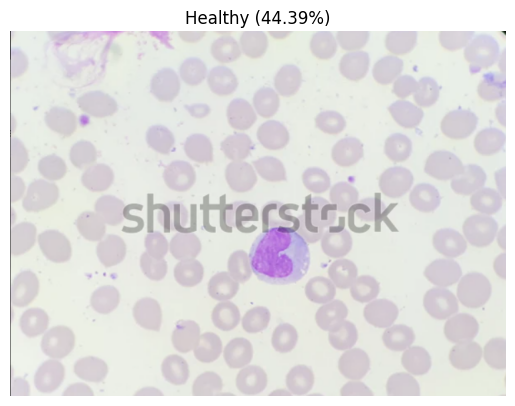

In [58]:
import matplotlib.pyplot as plt
from PIL import Image

for img_name in uploaded.keys():
    pred, conf = predict_image(img_name)

    img = Image.open(img_name)

    plt.imshow(img)
    plt.title(f"{pred} ({conf*100:.2f}%)")
    plt.axis("off")
    plt.show()